In [1]:
import numpy as np
from astropy.table import Table
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.stats import binned_statistic
from scipy.optimize import curve_fit
import pickle

from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(70,0.3,0.7)

import sys
sys.path.insert(0,'../g3code/')
from g3misc import *

def multf_model(logN, a, b):
    return a*logN + b

In [2]:
shark = Table.read('../catalogs/waves_g3_groups.fits').to_pandas()

deep = (shark.footprint<=2) & (shark.redshift_observed<=0.2)
shark.loc[deep,'subvol']=b'wide'
sv1 = (shark.footprint==3) & (shark.redshift_observed<=0.2)
shark.loc[sv1,'subvol']=b'deep_sv1'
sv2 = (shark.footprint==3) & (shark.redshift_observed>0.2) & (shark.redshift_observed<=0.4)
shark.loc[sv2,'subvol']=b'deep_sv2'
sv3 = (shark.footprint==3) & (shark.redshift_observed>0.4) & (shark.redshift_observed<=0.6)
shark.loc[sv3,'subvol']=b'deep_sv3'
sv4 = (shark.footprint==3) & (shark.redshift_observed>0.6) & (shark.redshift_observed<=0.8)
shark.loc[sv4,'subvol']=b'deep_sv4'

shark_observed = shark[shark.grpid > 0]

In [3]:
mosaic_map = dict(A=b'wide', B=b'deep_sv1', C=b'deep_sv2', D=b'deep_sv3', E=b'deep_sv4')
svlabels = dict(A='WAVES-Wide', B='WAVES-Deep-SV1', C='WAVES-Deep-SV2', D='WAVES-Deep-SV3', E='WAVES-Deep-SV4')

# Footprints and Volumes

In [4]:
# plt.figure(figsize=(4,4))
# plt.scatter(shark_observed.ra, shark_observed.dec, c=(shark_observed.footprint <= 2).astype(int)+1, cmap='jet_r',\
#            rasterized=True)
# plt.xlabel("RA [deg]",fontsize=14)
# plt.ylabel("Decl. [deg]",fontsize=14)
# plt.gca().invert_xaxis()
# plt.tight_layout()
# plt.savefig("../figures/footprints.png",dpi=300)
# plt.show()

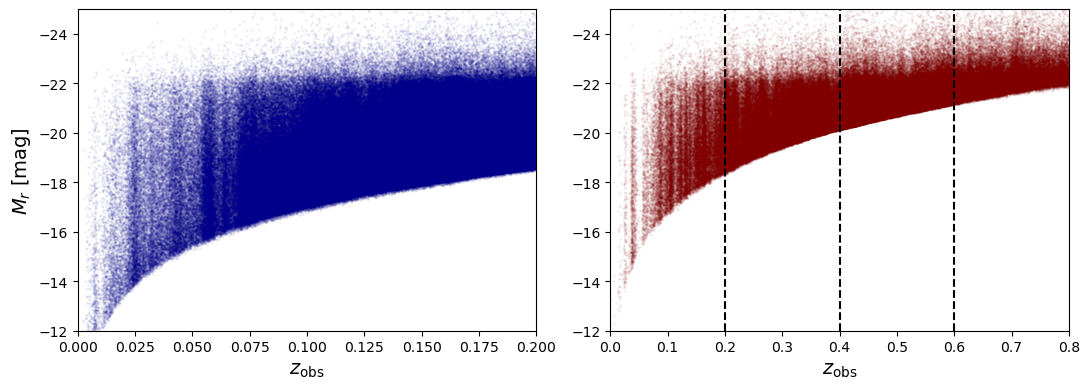

In [5]:
fig,axs = plt.subplots(ncols=2, figsize=(11,4))

wide = shark_observed[shark_observed.subvol == b'wide']
axs[0].scatter(wide.redshift_observed, wide.mag_abs_r_SDSS, s=1, alpha=0.05, color='darkblue', rasterized=True)
axs[0].set_xlim(0,0.2)
axs[0].set_ylabel(r'$M_r$ [mag]',fontsize=14)

deep = shark_observed[(shark_observed.subvol != 'na') & (shark_observed.subvol != b'wide')]
axs[1].scatter(deep.redshift_observed, deep.mag_abs_r_SDSS, s=1, alpha=0.05, color='maroon', rasterized=True)
axs[1].set_xlim(0,0.8)
for line in [0.2,0.4,0.6]:
    axs[1].axvline(line,color='k', linestyle='dashed')

for ax in axs:
    ax.set_ylim(-12,-25)
    ax.set_xlabel(r'$z_{\rm obs}$', fontsize=14)

plt.tight_layout()
plt.savefig("../figures/Mr-z.png",dpi=300)
plt.show()

# Multiplicity Function

In [6]:
nbins=np.arange(0.5,300.5,1)
nbinc = 0.5 * (nbins[1:] + nbins[:-1])

In [7]:
halon_true = multiplicity_function(shark.haloid, False)
halon_observed = multiplicity_function(shark_observed.haloid, False)
grpn = multiplicity_function(shark_observed.grpid, False)

In [8]:
halo_nN_true = np.histogram(halon_true, bins=nbins)[0]
halo_nN_obs = np.histogram(halon_observed, bins=nbins)[0]
grp_nN = np.histogram(grpn, bins=nbins)[0]

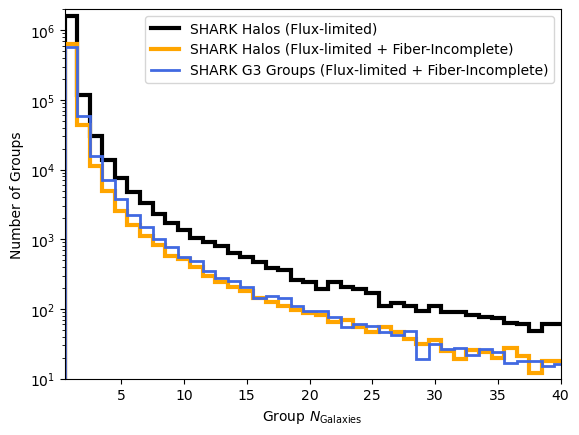

In [10]:
plt.figure()
plt.stairs(halo_nN_true, nbins, color='k', linewidth=3, label='SHARK Halos (Flux-limited)')
plt.stairs(halo_nN_obs, nbins, color='orange', linewidth=3, label='SHARK Halos (Flux-limited + Fiber-Incomplete)')
plt.stairs(grp_nN, nbins, color='royalblue', linewidth=2, label='SHARK G3 Groups (Flux-limited + Fiber-Incomplete)')
plt.yscale('log')
plt.xlim(0.5,40)
plt.ylim(1e1,2e6)
plt.legend(loc='upper right')
plt.xlabel(r'Group $N_{\rm Galaxies}$')
plt.ylabel("Number of Groups")
plt.savefig("../figures/multf.png",dpi=300)
plt.show()

In [11]:
sel = (nbinc <= 20)
popt_halo_true, pcov_halo_true = curve_fit(multf_model, np.log10(nbinc[sel]), np.log10(halo_nN_true[sel]))
popt_halo_obs, pcov_halo_obs = curve_fit(multf_model, np.log10(nbinc[sel]), np.log10(halo_nN_obs[sel]))
popt_grp, pcov_grp = curve_fit(multf_model, np.log10(nbinc[sel]), np.log10(grp_nN[sel]))

In [12]:
print("Best fits (global multiplicity function): ")
print("Halos ('true'): ", popt_halo_true, np.sqrt(np.diagonal(pcov_halo_true)))
print("Halos (obs): ", popt_halo_obs, np.sqrt(np.diagonal(pcov_halo_obs)))
print("Halos (groups): ", popt_grp, np.sqrt(np.diagonal(pcov_grp)))

Best fits (global multiplicity function): 
Halos ('true'):  [-2.74416218  5.91046253] [0.06419867 0.06301529]
Halos (obs):  [-2.80298576  5.50197684] [0.06671217 0.06548246]
Halos (groups):  [-2.82381495  5.60601057] [0.03889519 0.03817823]


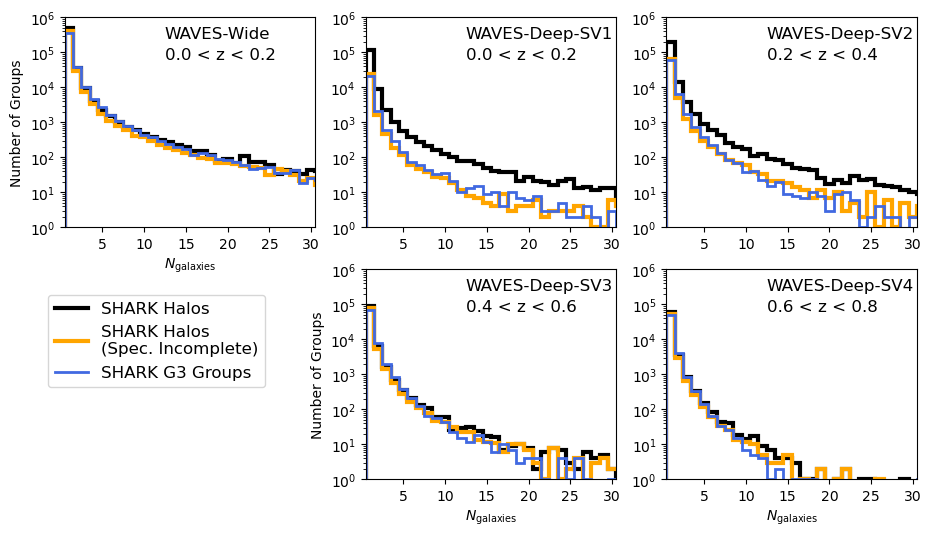

In [14]:
fig, axs = plt.subplot_mosaic('''ABC
                                 .DE''',figsize=(11,6))
for key in mosaic_map.keys():
    subset_complete = shark[shark.subvol == mosaic_map[key]]
    subset_complete_halon = multiplicity_function(subset_complete.haloid,False)
    subset_complete_nN = np.histogram(subset_complete_halon, bins=nbins)[0]
    
    subset = shark_observed[shark_observed.subvol == mosaic_map[key]]
    subset_halon_observed = multiplicity_function(subset.haloid, False)
    subset_grpn = multiplicity_function(subset.grpid, False)
    subset_halo_nN_obs = np.histogram(subset_halon_observed, bins=nbins)[0]
    subset_grp_nN = np.histogram(subset_grpn, bins=nbins)[0]

    axs[key].stairs(subset_complete_nN, nbins, color='k', linewidth=3, label='SHARK Halos')
    axs[key].stairs(subset_halo_nN_obs, nbins, color='orange', linewidth=3, label='SHARK Halos\n(Spec. Incomplete)')
    axs[key].stairs(subset_grp_nN, nbins, color='royalblue', linewidth=2, label='SHARK G3 Groups')
    axs[key].set_yscale('log')
    axs[key].set_xlim(0.5,30.5)
    axs[key].set_ylim(1e0,1e6)
    axs[key].annotate(xy=(0.4,0.9), xycoords='axes fraction', text=svlabels[key],fontsize=12)
    zlabel = f'{subset.redshift_observed.min():0.1f} < z < {subset.redshift_observed.max():0.1f}'
    axs[key].annotate(xy=(0.4,0.8), xycoords='axes fraction', text=zlabel,fontsize=12)
axs['A'].set_ylabel("Number of Groups")
axs['D'].set_ylabel("Number of Groups")
axs['A'].set_xlabel(r"$N_{\rm galaxies}$")
axs['D'].set_xlabel(r"$N_{\rm galaxies}$")
axs['E'].set_xlabel(r"$N_{\rm galaxies}$")
axs['A'].legend(loc='lower left', fontsize=12, bbox_to_anchor=(-0.1,-0.8))
#plt.tight_layout()
plt.savefig("../figures/multf_by_sv.png",dpi=300)
plt.show()

# Purity & Completeness with Reference to "Observed" Halos
make 5x2 plot (5 cols for all subvols, 2 rows for Pg and Cg); same for Ph, Ch

In [15]:
shark_observed.loc[:,'halon'] = multiplicity_function(shark_observed.loc[:,'haloid'], True)

/var/folders/8m/dhcvf5t90qb04kx2vn0wbvl00000gp/T/ipykernel_8725/2121370763.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shark_observed.loc[:,'halon'] = multiplicity_function(shark_observed.loc[:,'haloid'], True)


In [16]:
groups = shark_observed.groupby('grpid').first()
halos_obs = shark_observed.groupby('haloid').first()

In [17]:
bin2d = [np.arange(0.5,55.5,2),np.arange(0,1.05,0.05)]
pcnorm = LogNorm(vmin=1e0,vmax=1e6)

In [18]:
medianPg, binedges, _ = binned_statistic(groups.grpn, groups.Pg, bins=bin2d[0], statistic='median')
medianCg, binedges, _ = binned_statistic(groups.grpn, groups.Cg, bins=bin2d[0], statistic='median')
medianPh, binedges, _ = binned_statistic(halos_obs.halon, halos_obs.Ph, bins=bin2d[0], statistic='median')
medianCh, binedges, _ = binned_statistic(halos_obs.halon, halos_obs.Ch, bins=bin2d[0], statistic='median')
pcbinc = 0.5 * (binedges[1:] + binedges[:-1])

In [19]:
ecomock = pd.read_csv("../../ECO-halobiasmocks/ECO_cat_3_Planck_memb_cat.csv")
emgroups = ecomock.groupby('g3grp_l').first()
emhalos = ecomock.groupby('haloid').first()
medianPg_em, binedges, _ = binned_statistic(emgroups.g3grpn_l, emgroups.group_purity, bins=bin2d[0], statistic='median')
medianCg_em, binedges, _ = binned_statistic(emgroups.g3grpn_l, emgroups.group_comp, bins=bin2d[0], statistic='median')
medianPh_em, binedges, _ = binned_statistic(emhalos.halo_ngal, emhalos.halo_purity, bins=bin2d[0], statistic='median')
medianCh_em, binedges, _ = binned_statistic(emhalos.halo_ngal, emhalos.halo_comp, bins=bin2d[0], statistic='median')

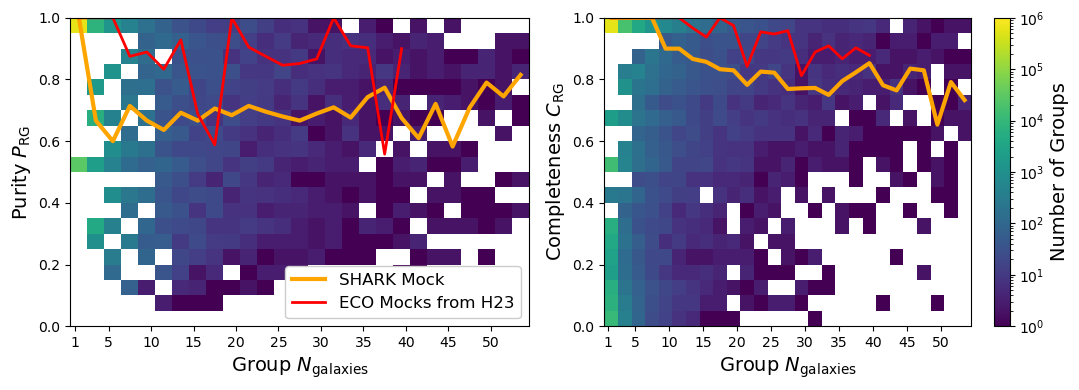

In [21]:
fig, axs = plt.subplots(ncols=2, figsize=(11,4))
axs[0].hist2d(groups.grpn, groups.Pg, norm=pcnorm, bins=bin2d)
axs[0].plot(pcbinc, medianPg, color='orange', linewidth=3, label='SHARK Mock')
axs[0].plot(pcbinc[:20], medianPg_em[:20], color='red', linewidth=2, label='ECO Mocks from H23')
axs[0].set_ylabel(r"Purity $P_{\rm RG}$", fontsize=14)
axs[0].legend(loc='lower right', fontsize=12,framealpha=1)
#axs[0].annotate(xy=(12,0.58), text=r'median $P_g$', color='orange', fontsize=14)

hist2d=axs[1].hist2d(groups.grpn, groups.Cg, norm=pcnorm, bins=bin2d)
axs[1].plot(pcbinc, medianCg, color='orange', linewidth=3)
axs[1].plot(pcbinc[:20], medianCg_em[:20], color='red', linewidth=2)
axs[1].set_ylabel(r"Completeness $C_{\rm RG}$",fontsize=14)
#axs[1].annotate(xy=(12,0.53), text=r'median $C_g$', color='orange', fontsize=14)

cb = fig.colorbar(hist2d[-1])
cb.set_label("Number of Groups",fontsize=14)
for ax in axs:
    ax.set_xlabel(r"Group $N_{\rm galaxies}$",fontsize=14)
    ax.set_xticks([1]+list(np.arange(5,55,5)))
plt.tight_layout()
plt.savefig("../figures/Pg-Cg.png",dpi=300)
plt.show()

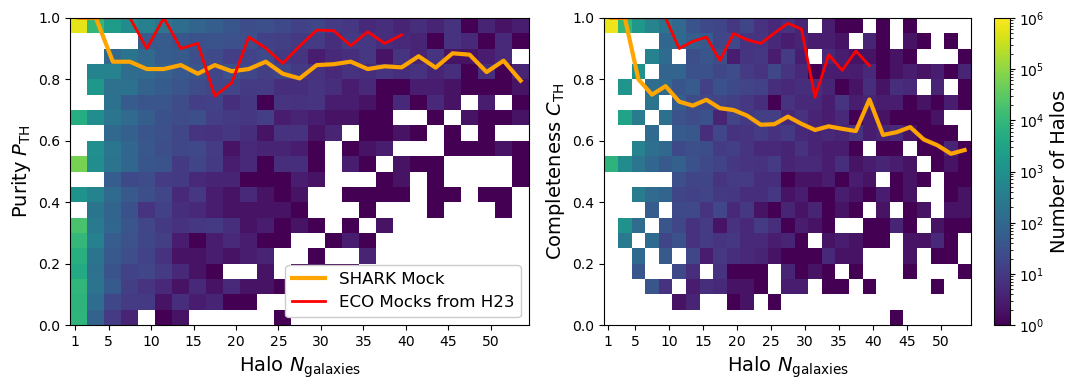

In [25]:
fig, axs = plt.subplots(ncols=2, figsize=(11,4))
axs[0].hist2d(halos_obs.halon, halos_obs.Ph, norm=pcnorm, bins=bin2d)
axs[0].plot(pcbinc, medianPh, color='orange', linewidth=3, label='SHARK Mock')
axs[0].plot(pcbinc[:20], medianPh_em[:20], color='red', linewidth=2, label='ECO Mocks from H23')
axs[0].set_ylabel(r"Purity $P_{\rm TH}$", fontsize=14)
axs[0].legend(loc='lower right', fontsize=12,framealpha=1)
#axs[0].annotate(xy=(15,0.75), text=r'median $P_h$', color='orange', fontsize=14)

hist2d=axs[1].hist2d(halos_obs.halon, halos_obs.Ch, norm=pcnorm, bins=bin2d)
axs[1].plot(pcbinc, medianCh, color='orange', linewidth=3)
axs[1].plot(pcbinc[:20], medianCh_em[:20], color='red', linewidth=2)
axs[1].set_ylabel(r"Completeness $C_{\rm TH}$",fontsize=14)
#axs[1].annotate(xy=(20,0.57), text=r'median $C_h$', color='orange', fontsize=14)

cb = fig.colorbar(hist2d[-1])
cb.set_label("Number of Halos",fontsize=14)
for ax in axs:
    ax.set_xlabel(r"Halo $N_{\rm galaxies}$",fontsize=14)
    ax.set_xticks([1]+list(np.arange(5,55,5)))
plt.tight_layout()
plt.savefig("../figures/Ph-Ch.png",dpi=300)
plt.show()

In [ ]:
tmp_ = groups[(groups.grpn>=2)]

print("Mean P and C", np.mean(tmp_.Pg), np.mean(tmp_.Cg))
print("Frac >60% P and C", ((tmp_.Pg > 0.6) & (tmp_.Cg > 0.6)).sum() / len(tmp_))

In [ ]:
tmp_ = halos_obs[halos_obs.halon>=2]
print("Mean P and C", np.mean(tmp_.Ph), np.mean(tmp_.Ch))
print("Frac >70% P or C", ((tmp_.Ph > 0.7) & (tmp_.Ch > 0.7)).sum() / len(tmp_))

In [ ]:
mbin2d=[np.arange(10,16,1),np.arange(0,1.05,0.05)]
medianPh, binedges, _ = binned_statistic(np.log10(halos_obs.mass_virial_hosthalo), halos_obs.Ph, bins=mbin2d[0], statistic='median')
medianCh, binedges, _ = binned_statistic(np.log10(halos_obs.mass_virial_hosthalo), halos_obs.Ch, bins=mbin2d[0], statistic='median')
mbin2dc = 0.5 * (binedges[1:] + binedges[:-1])

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(11,4))
axs[0].hist2d(np.log10(halos_obs.mass_virial_hosthalo), halos_obs.Ph, norm=pcnorm, bins=mbin2d)
axs[0].set_ylabel("Purity $P_h$", fontsize=14)
axs[0].plot(mbin2dc, medianPh, color='orange', linewidth=3)
axs[0].annotate(xy=(12,0.58), text=r'median $P_h$', color='orange', fontsize=14)

hist2d=axs[1].hist2d(np.log10(halos_obs.mass_virial_hosthalo), halos_obs.Ch, norm=pcnorm, bins=mbin2d)
axs[1].plot(mbin2dc, medianCh, color='orange', linewidth=3)
axs[1].set_ylabel("Completeness $C_h$",fontsize=14)
axs[1].annotate(xy=(12,0.58), text=r'median $C_h$', color='orange', fontsize=14)

cb = fig.colorbar(hist2d[-1])
cb.set_label("Number of Halos",fontsize=14)
for ax in axs:
    ax.set_xlabel(r"Log Simulation Halo Mass",fontsize=14)
plt.tight_layout()
plt.show()

### Same, but now broken up by subvolume + with more coarse binning

In [ ]:
bin2d = [np.arange(0.5,55.5,4),np.arange(0,1.05,0.05)]
pcbinc = 0.5 * (bin2d[0][1:] + bin2d[0][:-1])

In [ ]:
fig, axs = plt.subplots(ncols=2, nrows=5, figsize=(11,20))
for ii,key in enumerate(mosaic_map.keys()):
    tmp_groups = groups[groups.subvol == mosaic_map[key]]
    medianPg, binedges, _ = binned_statistic(tmp_groups.grpn, tmp_groups.Pg, bins=bin2d[0], statistic='median')
    medianCg, binedges, _ = binned_statistic(tmp_groups.grpn, tmp_groups.Cg, bins=bin2d[0], statistic='median')
    axs[ii,0].hist2d(tmp_groups.grpn, tmp_groups.Pg, norm=pcnorm, bins=bin2d)
    axs[ii,0].plot(pcbinc, medianPg, color='orange', linewidth=3)
    axs[ii,1].hist2d(tmp_groups.grpn, tmp_groups.Cg, norm=pcnorm, bins=bin2d)
    axs[ii,1].plot(pcbinc, medianCg, color='orange', linewidth=3)
    
    axs[ii,0].set_ylabel('Purity $P_g$',fontsize=12)
    axs[ii,1].set_ylabel('Purity $C_g$',fontsize=12)
    for jj in range(2): axs[ii,jj].annotate(xy=(0.6,0.1), xycoords='axes fraction', text=svlabels[key], fontsize=14, backgroundcolor='white')
axs[-1,0].set_xlabel(r"Group $N_{\rm galaxies}$",fontsize=12)
axs[-1,1].set_xlabel(r"Group $N_{\rm galaxies}$",fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
fig, axs = plt.subplots(ncols=2, nrows=5, figsize=(11,20))
for ii,key in enumerate(mosaic_map.keys()):
    tmp_halos = halos_obs[halos_obs.subvol == mosaic_map[key]]
    medianPh, binedges, _ = binned_statistic(tmp_halos.halon, tmp_halos.Ph, bins=bin2d[0], statistic='median')
    medianCh, binedges, _ = binned_statistic(tmp_halos.halon, tmp_halos.Ch, bins=bin2d[0], statistic='median')
    axs[ii,0].hist2d(tmp_halos.halon, tmp_halos.Ph, norm=pcnorm, bins=bin2d)
    axs[ii,0].plot(pcbinc, medianPh, color='orange', linewidth=3)
    axs[ii,1].hist2d(tmp_halos.halon, tmp_halos.Ch, norm=pcnorm, bins=bin2d)
    axs[ii,1].plot(pcbinc, medianCh, color='orange', linewidth=3)
    
    axs[ii,0].set_ylabel('Purity $P_h$',fontsize=12)
    axs[ii,1].set_ylabel('Purity $C_h$',fontsize=12)
    for jj in range(2): axs[ii,jj].annotate(xy=(0.6,0.1), xycoords='axes fraction', text=svlabels[key], fontsize=14, backgroundcolor='white')
axs[-1,0].set_xlabel(r"Halo $N_{\rm galaxies}$",fontsize=12)
axs[-1,1].set_xlabel(r"Halo $N_{\rm galaxies}$",fontsize=12)
plt.tight_layout()
plt.show()

# Group Redshifts

you need to look at this as a function of purity and completeness, I think, for matched groups and halos

In [ ]:
halos_obs_z=halos_obs.set_index('matchedgrp')[['redshift_cosmological','halon']]

In [ ]:
groups_z_df = groups[['grpz','grpn','subvol']]

In [ ]:
joined = groups_z_df.join(halos_obs_z)

In [ ]:
fig, axs = plt.subplot_mosaic('''ABC
                                 .DE''',figsize=(11,6))
for key in mosaic_map.keys():
    subset = joined[joined.subvol == mosaic_map[key]]
    subset = subset[~subset.grpz.isna() & ~subset.redshift_cosmological.isna() & (subset.halon>1)]
    dz = subset.redshift_cosmological - subset.grpz

    zbin2d = [np.arange(subset.redshift_cosmological.min(), subset.redshift_cosmological.max(), 0.005),\
              np.arange(-0.01,0.01,0.0001)]
    axs[key].hist2d(subset.redshift_cosmological, dz, bins=zbin2d)
    axs[key].set_ylim(-0.004,0.004)
    axs[key].annotate(xy=(0.4,0.9), xycoords='axes fraction', text=svlabels[key], color='yellow',fontsize=12)
    
axs['A'].set_ylabel(r"$z_{\rm cos} - z_{\rm G3}$",fontsize=14)
axs['D'].set_ylabel(r"$z_{\rm cos} - z_{\rm G3}$",fontsize=14)
axs['A'].set_xlabel(r"$z_{\rm cos}$",fontsize=14)
axs['D'].set_xlabel(r"$z_{\rm cos}$",fontsize=14)
axs['E'].set_xlabel(r"$z_{\rm cos}$",fontsize=14)
plt.tight_layout()
plt.savefig("../figures/dz.png",dpi=300)
plt.show()

# What percentage of multi-galaxy halos would be split by strict edge cuts?

In [ ]:
multigal_halos = shark_observed[shark_observed.halon >= 2]

In [ ]:
haloz_stats = multigal_halos.groupby('haloid').grpz.describe()[['min','max']]

In [ ]:
split1 = (haloz_stats['min'] < 0.2) & (haloz_stats['max'] > 0.2)
split2 = (haloz_stats['min'] < 0.4) & (haloz_stats['max'] > 0.4)
split3 = (haloz_stats['min'] < 0.6) & (haloz_stats['max'] > 0.6)
split = split1 | split2 | split3

In [ ]:
np.sum(split)

In [ ]:
np.sum(split) / len(haloz_stats) * 100